In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

## 침식 연산

In [2]:
src = np.zeros((7,7), dtype = np.uint8)
src[:, 2: 5] = 255
src

array([[  0,   0, 255, 255, 255,   0,   0],
       [  0,   0, 255, 255, 255,   0,   0],
       [  0,   0, 255, 255, 255,   0,   0],
       [  0,   0, 255, 255, 255,   0,   0],
       [  0,   0, 255, 255, 255,   0,   0],
       [  0,   0, 255, 255, 255,   0,   0],
       [  0,   0, 255, 255, 255,   0,   0]], dtype=uint8)

In [ ]:
H = src.shape[0]
W = src.shape[1]

mask = np.full((3,3), 1)
mask_H = 3
mask_W = 3

dst = np.zeros_like(src).astype(float)

for h in range(1, H-1):
    for w in range(1, W-1):
        roi = src[h-1 : h-1+mask_H , w-1 : w-1+mask_W]
        dst[h,w] = np.min(roi * mask)

dst

array([[  0.,   0.,   0.,   0.,   0.,   0.,   0.],
       [  0.,   0.,   0., 255.,   0.,   0.,   0.],
       [  0.,   0.,   0., 255.,   0.,   0.,   0.],
       [  0.,   0.,   0., 255.,   0.,   0.,   0.],
       [  0.,   0.,   0., 255.,   0.,   0.,   0.],
       [  0.,   0.,   0., 255.,   0.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   0.,   0.,   0.]])

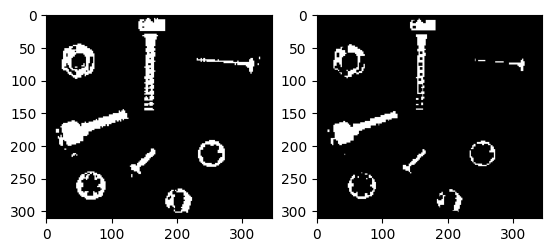

In [5]:
# 실제 이미지에 적용

src = cv2.imread("images/screws_binary_sample.jpg")
src = src[:,:,0]

src = np.where(src > 127 , 255, 0)

H = src.shape[0]
W = src.shape[1]

mask_size = 3

dst = np.zeros_like(src).astype(np.uint8)

for h in range(1, H-1):
    for w in range(1, W-1):
        roi = src[h-1 : h-1+mask_size , w-1 : w-1+mask_size]
        dst[h,w] = np.min(roi)


plt.subplot(1,2,1 )
plt.imshow(src, cmap = 'gray')
plt.subplot(1,2,2)
plt.imshow(dst , cmap = 'gray')

## 팽창 연산

최솟값이 아닌 최댓값을 기준으로 채워넣으면 됨

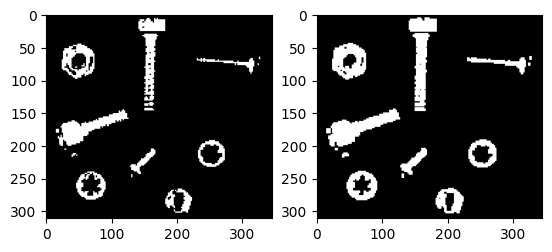

In [6]:
# 실제 이미지에 적용

src = cv2.imread("images/screws_binary_sample.jpg")
src = src[:,:,0]

src = np.where(src > 127 , 255, 0)

H = src.shape[0]
W = src.shape[1]

mask_size = 3

dst = np.zeros_like(src).astype(np.uint8)

for h in range(1, H-1):
    for w in range(1, W-1):
        roi = src[h-1 : h-1+mask_size , w-1 : w-1+mask_size]
        dst[h,w] = np.max(roi)


plt.subplot(1,2,1 )
plt.imshow(src, cmap = 'gray')
plt.subplot(1,2,2)
plt.imshow(dst , cmap = 'gray')